# SAED Workflows

This notebook demonstrates the current selected-area electron diffraction workflow
built around explicit reciprocal-space and detector semantics. The main teaching case
now uses the pinned `ni_fcc` fixture that also anchors the first external shell-
geometry baseline.


In [1]:
from pathlib import Path
import tempfile

import numpy as np

from pytex import (
    AcquisitionGeometry,
    AtomicSite,
    BenchmarkManifest,
    build_crystal_scene,
    CalibrationRecord,
    CrystalCellOverlay,
    CrystalDirection,
    CrystalDirectionOverlay,
    CrystalMap,
    CrystalPlane,
    CrystalPlaneOverlay,
    DirectionAnnotationStyle,
    DiffractionGeometry,
    EulerSet,
    ExperimentManifest,
    FrameDomain,
    FrameTransform,
    Handedness,
    InversePoleFigure,
    KernelSpec,
    KinematicSimulation,
    Lattice,
    get_phase_fixture,
    list_phase_fixtures,
    list_style_themes,
    MeasurementQuality,
    MillerIndex,
    ODF,
    Orientation,
    OrientationRelationship,
    OrientationSet,
    Phase,
    PhaseTransformationRecord,
    PoleFigure,
    PowderPattern,
    PowderReflection,
    ReferenceFrame,
    read_validation_manifest,
    read_workflow_result_manifest,
    resolve_style,
    RadiationSpec,
    Rotation,
    ScatteringSetup,
    SymmetrySpec,
    TransformationVariant,
    UnitCell,
    ValidationManifest,
    VectorSet,
    WorkflowResultManifest,
    ZoneAxis,
    PlaneAnnotationStyle,
    generate_saed_pattern,
    generate_xrd_pattern,
    normalize_ebsd,
    plot_odf,
    plot_crystal_structure_3d,
    plot_inverse_pole_figure,
    plot_ipf_map,
    plot_orientations,
    plot_kam_map,
    plot_pole_figure,
    plot_saed_pattern,
    plot_symmetry_elements,
    plot_symmetry_orbit,
    plot_vector_set,
    plot_xrd_pattern,
)


def make_crystal_frame():
    return ReferenceFrame(
        "crystal",
        FrameDomain.CRYSTAL,
        ("a", "b", "c"),
        Handedness.RIGHT,
    )


def make_context():
    crystal = make_crystal_frame()
    specimen = ReferenceFrame(
        "specimen",
        FrameDomain.SPECIMEN,
        ("x", "y", "z"),
        Handedness.RIGHT,
    )
    map_frame = ReferenceFrame(
        "map",
        FrameDomain.MAP,
        ("i", "j", "k"),
        Handedness.RIGHT,
    )
    detector = ReferenceFrame(
        "detector",
        FrameDomain.DETECTOR,
        ("u", "v", "n"),
        Handedness.RIGHT,
    )
    lab = ReferenceFrame(
        "lab",
        FrameDomain.LABORATORY,
        ("X", "Y", "Z"),
        Handedness.RIGHT,
    )
    phase = get_phase_fixture("ni_fcc").load_phase(crystal_frame=crystal)
    return crystal, specimen, map_frame, detector, lab, phase


def describe_phase_fixture(fixture_id):
    record = get_phase_fixture(fixture_id)
    return {
        "fixture_id": record.fixture_id,
        "display_name": record.display_name,
        "artifact_path": str(record.artifact_path),
        "metadata_path": str(record.metadata_path),
        "intended_uses": tuple(record.metadata["intended_uses"]),
    }


def load_zr_hcp_phase():
    return get_phase_fixture("zr_hcp").load_phase(crystal_frame=make_crystal_frame())


def load_diamond_phase():
    return get_phase_fixture("diamond").load_phase(crystal_frame=make_crystal_frame())


def publication_crystal_style():
    return {
        "crystal": {
            "atom_radius_scale": 0.5,
            "atom_edgewidth": 0.0,
            "atom_surface_resolution": 34,
            "bond_surface_resolution": 28,
            "bond_alpha": 0.72,
            "bond_color": "#7c8ea3",
            "atom_specular_strength": 0.42,
            "light_specular": 0.4,
        }
    }


In [2]:
crystal, specimen, map_frame, detector, lab, phase = make_context()
reference_fixture = describe_phase_fixture("ni_fcc")
zone_axis = ZoneAxis(indices=np.array([0, 0, 1]), phase=phase)
saed = generate_saed_pattern(
    phase,
    zone_axis,
    camera_constant_mm_angstrom=180.0,
    max_index=5,
    max_g_inv_angstrom=3.0,
)

print("Fixture:", reference_fixture["display_name"])
print("zone axis:", saed.zone_axis.indices)
print("spots:", len(saed.spots))
print("detector frame:", saed.detector_frame.name)


Fixture: Nickel (FCC)
zone axis: [0 0 1]
spots: 120
detector frame: nickel-fcc_saed_detector


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pymatgen/io/cif.py:720: UserWarning: No _symmetry_equiv_pos_as_xyz type key found. Spacegroup from _symmetry_space_group_name_H-M used.
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pymatgen/io/cif.py:1224: UserWarning: Issues encountered while parsing CIF: No _symmetry_equiv_pos_as_xyz type key found. Spacegroup from _symmetry_space_group_name_H-M used.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


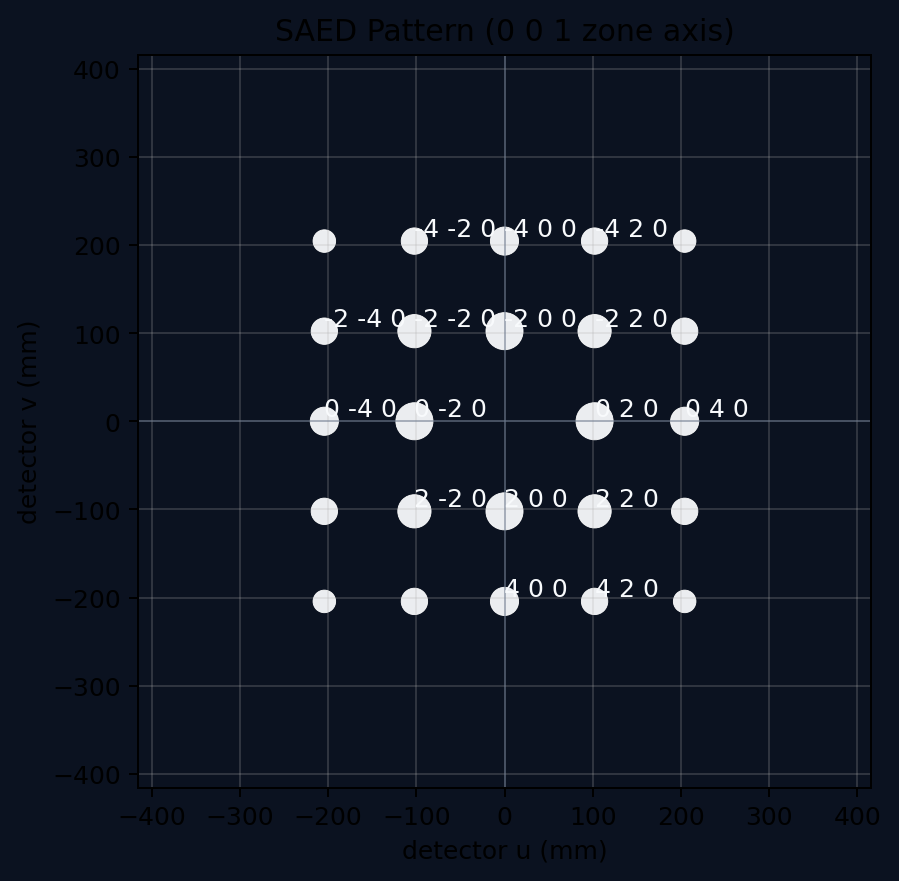

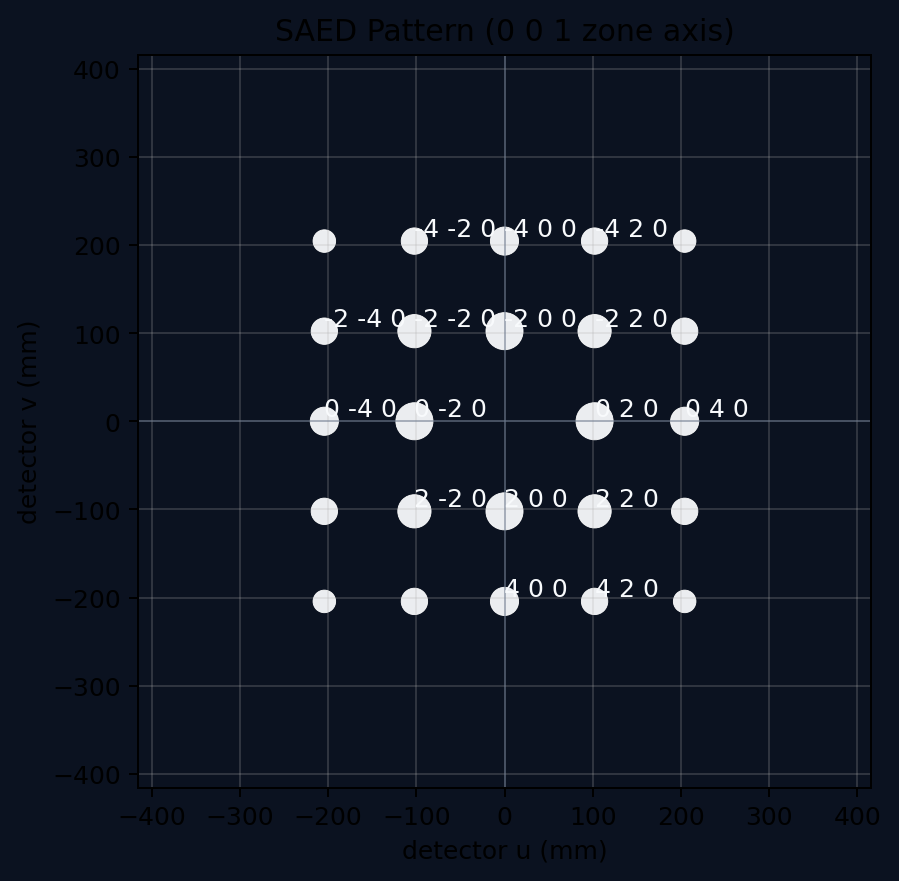

In [3]:
figure = plot_saed_pattern(saed, theme="dark")
figure


PyTex keeps the direct-space zone axis, reciprocal-space reflections, and
detector-space coordinates explicit rather than collapsing them into one plotting
array.

The current spot intensities are proxy values for ranking and display. The pinned
validation case for this notebook is geometry-first and checks indexed shell
agreement against a `diffsims` reference artifact rather than claiming a full
dynamical electron-diffraction model.
